# Chapter 6 — Abstract Linear (Vector) Spaces

Numerical companion to `notes.md`. We treat polynomials, matrices, and "Fourier-like" function combinations as vector spaces and run the Ch 1–5 machine on them via **coordinates**.

What we'll do:

1. Represent polynomials as coefficient vectors — `Pₙ ≅ ℝⁿ⁺¹`.
2. Build the matrix `[D]` of the **derivative** as a 4×4 matrix on `P₃`. Calculus by `numpy.matmul`.
3. Build the matrix `[I]` of **integration** (antiderivative with `C = 0`) and verify `D ∘ I = id`.
4. Test linear independence in `P₃` via coordinate stacking and rank.
5. Convert between two bases of `P₂` — including the **Lagrange basis** where coordinates *are* function values.
6. Verify the similarity formula `[T]_{𝓑'} = P [T]_𝓑 P⁻¹` for `T(p) = p + p'`.
7. Build the matrix of the derivative on the **5-dim subspace** of `C^∞` spanned by `1, cos x, sin x, cos 2x, sin 2x`.
8. Application: **polynomial interpolation** as a single basis-change matrix.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## 1. Polynomials as vectors

We represent a polynomial of degree ≤ `n` by its coefficient vector `(a₀, a₁, …, aₙ)` so that the polynomial is `a₀ + a₁ x + ⋯ + aₙ xⁿ`. Addition and scalar multiplication of polynomials become addition and scalar multiplication of coefficient vectors — that is, `Pₙ ≅ ℝⁿ⁺¹`.

In [2]:
def poly_str(coeffs):
    """Format coefficient vector as a polynomial string."""
    terms = []
    for i, c in enumerate(coeffs):
        if abs(c) < 1e-12:
            continue
        c_str = f'{c:g}'
        if i == 0:
            terms.append(c_str)
        elif i == 1:
            terms.append(f'{c_str}*x')
        else:
            terms.append(f'{c_str}*x^{i}')
    return ' + '.join(terms) if terms else '0'


def poly_eval(coeffs, x):
    """Evaluate polynomial at x (Horner-style for stability)."""
    result = 0.0
    for c in reversed(coeffs):
        result = result * x + c
    return result


# Example
p = np.array([3, 2, 0, 1])   # 3 + 2x + x^3
q = np.array([1, -1, 4, 0])  # 1 - x + 4x^2

print('p(x) =', poly_str(p))
print('q(x) =', poly_str(q))
print('(p + q)(x) =', poly_str(p + q))
print('5*p(x) =', poly_str(5 * p))
print('p(2) =', poly_eval(p, 2.0), '   (expect 3 + 4 + 8 = 15)')

p(x) = 3 + 2*x + 1*x^3
q(x) = 1 + -1*x + 4*x^2
(p + q)(x) = 4 + 1*x + 4*x^2 + 1*x^3
5*p(x) = 15 + 10*x + 5*x^3
p(2) = 15.0    (expect 3 + 4 + 8 = 15)


## 2. Differentiation as a matrix

The derivative `D: P₃ → P₃` (we keep the codomain as `P₃` so the matrix is square) is linear:

```
   D(a₀ + a₁ x + a₂ x² + a₃ x³)  =  a₁ + 2 a₂ x + 3 a₃ x²  +  0 · x³.
```

In coefficient form: `(a₀, a₁, a₂, a₃)` ↦ `(a₁, 2 a₂, 3 a₃, 0)`. That's a matrix multiplication.

In [3]:
def derivative_matrix(n):
    """Matrix of D on P_n in basis (1, x, ..., x^n). Square (n+1)×(n+1)."""
    D = np.zeros((n + 1, n + 1))
    for k in range(1, n + 1):
        D[k - 1, k] = k
    return D


D = derivative_matrix(3)
print('Matrix of derivative on P_3 (basis 1, x, x^2, x^3):')
print(D)

Matrix of derivative on P_3 (basis 1, x, x^2, x^3):
[[0. 1. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 3.]
 [0. 0. 0. 0.]]


In [4]:
# Sanity check: differentiate p(x) = 3 + 2x + x^3
p = np.array([3, 2, 0, 1])
dp = D @ p
print('p(x)  =', poly_str(p))
print("p'(x) =", poly_str(dp), '   (expected: 2 + 3x^2)')

p(x)  = 3 + 2*x + 1*x^3
p'(x) = 2 + 3*x^2    (expected: 2 + 3x^2)


## 3. Integration as a matrix

Antiderivative with constant of integration `0`: `I(xᵏ) = x^{k+1} / (k+1)`. As a map `P₃ → P₃` it loses the leading coefficient (since `I(x³) = x⁴ / 4 ∉ P₃`). To stay inside `P₃` we **truncate**: integrate `a₀ + a₁ x + a₂ x² + a₃ x³` to `a₀ x + (a₁ / 2) x² + (a₂ / 3) x³` (dropping the `x⁴` term).

This truncated `I` is no longer the true antiderivative of degree-3 polynomials — but it's still a linear map, and `D ∘ I = id` on `P₂` (which sits inside `P₃` as polynomials with `a₃ = 0`). To get a proper antiderivative without truncation we'd let the codomain be `P₄` — which we do in Exercise 4 of `exercises.md`.

In [5]:
def integration_matrix_truncated(n):
    """Matrix of antiderivative (C=0), truncated to P_n. (n+1)×(n+1)."""
    I = np.zeros((n + 1, n + 1))
    for k in range(0, n):
        I[k + 1, k] = 1.0 / (k + 1)
    return I


I3 = integration_matrix_truncated(3)
print('Matrix of truncated antiderivative on P_3:')
print(I3)
print()
print('D @ I3 (should equal identity on coefficients of degree <= 2):')
print(D @ I3)
print()
print('I3 @ D (should kill the constant term but preserve x, x^2, x^3):')
print(I3 @ D)

Matrix of truncated antiderivative on P_3:
[[0.     0.     0.     0.    ]
 [1.     0.     0.     0.    ]
 [0.     0.5    0.     0.    ]
 [0.     0.     0.3333 0.    ]]

D @ I3 (should equal identity on coefficients of degree <= 2):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]]

I3 @ D (should kill the constant term but preserve x, x^2, x^3):
[[0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


## 4. Linear independence in `P₃` via coordinates

To test whether `p₁, p₂, p₃ ∈ P₃` are independent, stack their coefficient vectors as columns of a matrix and count pivots — same algorithm as Ch 5. We use NumPy's rank function.

In [6]:
# Worked Example E4: are p1 = 1 + x + x^2, p2 = x + x^2 + x^3, p3 = 1 + x^3 independent?
p1 = np.array([1, 1, 1, 0])
p2 = np.array([0, 1, 1, 1])
p3 = np.array([1, 0, 0, 1])
M = np.column_stack([p1, p2, p3])
print('Stacked coordinate matrix (columns are p1, p2, p3):')
print(M)
print('Rank =', np.linalg.matrix_rank(M), '  (== 3 means independent)')

Stacked coordinate matrix (columns are p1, p2, p3):
[[1 0 1]
 [1 1 0]
 [1 1 0]
 [0 1 1]]
Rank = 3   (== 3 means independent)


In [7]:
# Quick variant: are p1 = 1 + x, p2 = 1 - x, p3 = 1 + x^2, p4 = 1 - x^2 independent in P_3?
P = np.column_stack([
    [1, 1, 0, 0],
    [1, -1, 0, 0],
    [1, 0, 1, 0],
    [1, 0, -1, 0],
])
print('Rank =', np.linalg.matrix_rank(P), '  (4 vectors in P_3 = R^4; rank 4 means independent)')
# The fourth row is all zero, which collapses the rank below 4.

Rank = 3   (4 vectors in P_3 = R^4; rank 4 means independent)


## 5. Coordinates in a non-standard basis — including the Lagrange basis

The **Lagrange basis** for `P₂` at nodes `x₀, x₁, x₂` is the unique basis `(ℓ₀, ℓ₁, ℓ₂)` with `ℓⱼ(xᵢ) = δᵢⱼ`. Then **the coordinates of any `p ∈ P₂` in the Lagrange basis are simply `(p(x₀), p(x₁), p(x₂))`**. This is a beautiful payoff of the Ch 6 abstraction.

In [8]:
def lagrange_basis_change_matrix(nodes):
    """
    Returns the matrix S whose columns are the standard-basis coordinates of the
    Lagrange basis polynomials at the given nodes.
    Equivalently, S[:, j] = coefficients of l_j as a polynomial in the standard basis.
    """
    n = len(nodes)
    S = np.zeros((n, n))
    for j in range(n):
        # Build l_j as a product, then expand
        coeffs = np.array([1.0])  # constant polynomial 1
        denom = 1.0
        for i in range(n):
            if i == j:
                continue
            # Multiply by (x - nodes[i])
            new_coeffs = np.zeros(len(coeffs) + 1)
            new_coeffs[1:] += coeffs       # x * coeffs
            new_coeffs[:-1] -= nodes[i] * coeffs  # -nodes[i] * coeffs
            coeffs = new_coeffs
            denom *= (nodes[j] - nodes[i])
        coeffs /= denom
        S[:, j] = coeffs
    return S


nodes = np.array([0.0, 1.0, 2.0])
S = lagrange_basis_change_matrix(nodes)
print('Lagrange basis change matrix S (columns = l_0, l_1, l_2 in standard basis):')
print(S)

Lagrange basis change matrix S (columns = l_0, l_1, l_2 in standard basis):
[[ 1.  -0.   0. ]
 [-1.5  2.  -0.5]
 [ 0.5 -1.   0.5]]


In [9]:
# Worked Example 10: p(x) = 3 + 2x - x^2 in the Lagrange basis at nodes 0, 1, 2
p_std = np.array([3, 2, -1])  # coords in standard basis (1, x, x^2)

# Coordinates in Lagrange basis = function values at the nodes
p_lag = np.array([poly_eval(p_std, x) for x in nodes])
print('p in standard basis:', p_std)
print('p in Lagrange basis (= values at nodes):', p_lag, '  (expected: (3, 4, 3))')

# Verify: S * p_lag should reconstruct p_std
print('S @ p_lag (should equal p_std):', S @ p_lag)

p in standard basis: [ 3  2 -1]
p in Lagrange basis (= values at nodes): [3. 4. 3.]   (expected: (3, 4, 3))
S @ p_lag (should equal p_std): [ 3.  2. -1.]


## 6. Change of basis for a linear transformation: similarity

Verify the similarity formula `[T]_{𝓑'} = P [T]_𝓑 P⁻¹` from §6.9 on the operator `T: P₂ → P₂` defined by `T(p) = p + p'` (worked example E9).

In [10]:
# T(p) = p + p' on P_2.
# In the standard basis (1, x, x^2):
#   T(1)   = 1            -> (1, 0, 0)
#   T(x)   = x + 1        -> (1, 1, 0)
#   T(x^2) = x^2 + 2x     -> (0, 2, 1)
T_std = np.array([
    [1, 1, 0],
    [0, 1, 2],
    [0, 0, 1],
], dtype=float)

# Alternate basis B' = (1, 1+x, 1+x+x^2). The change-of-basis matrix
# P_inv := [id]_{B <- B'} has columns = B'-vectors expressed in standard basis:
P_inv = np.array([
    [1, 1, 1],
    [0, 1, 1],
    [0, 0, 1],
], dtype=float)
P = np.linalg.inv(P_inv)
print('P (standard -> B\'):')
print(P)

T_Bprime_direct = np.array([
    [1, 1, -1],
    [0, 1,  2],
    [0, 0,  1],
], dtype=float)
T_Bprime_via_similarity = P @ T_std @ P_inv
print()
print('[T]_B\' computed via similarity P [T] P^-1:')
print(T_Bprime_via_similarity)
print()
print('Direct [T]_B\' from worked example E9:')
print(T_Bprime_direct)
print()
print('Match?', np.allclose(T_Bprime_direct, T_Bprime_via_similarity))

P (standard -> B'):
[[ 1. -1.  0.]
 [ 0.  1. -1.]
 [ 0.  0.  1.]]

[T]_B' computed via similarity P [T] P^-1:
[[ 1.  1. -1.]
 [ 0.  1.  2.]
 [ 0.  0.  1.]]

Direct [T]_B' from worked example E9:
[[ 1.  1. -1.]
 [ 0.  1.  2.]
 [ 0.  0.  1.]]

Match? True


## 7. Derivative on a 5-dim function subspace

Let `V = span(1, cos x, sin x, cos 2x, sin 2x) ⊂ C^∞(ℝ)`. The derivative restricts to a linear map `V → V`. Building its matrix is a Ch 6 exercise (E9 in `exercises.md`).

In [11]:
# Basis B = (1, cos x, sin x, cos 2x, sin 2x). Derivative actions:
#   D(1) = 0           -> (0,0,0,0,0)
#   D(cos x) = -sin x  -> (0,0,-1,0,0)
#   D(sin x) =  cos x  -> (0,1, 0,0,0)
#   D(cos 2x) = -2 sin 2x -> (0,0,0, 0,-2)
#   D(sin 2x) =  2 cos 2x -> (0,0,0, 2, 0)
D_V = np.array([
    [0,  0,  0,  0,  0],
    [0,  0,  1,  0,  0],
    [0, -1,  0,  0,  0],
    [0,  0,  0,  0,  2],
    [0,  0,  0, -2,  0],
], dtype=float)
print('Matrix of D on V in basis (1, cos x, sin x, cos 2x, sin 2x):')
print(D_V)
print()
print('Rank =', np.linalg.matrix_rank(D_V), '  (=> nullity = 1; ker D = span(1))')

Matrix of D on V in basis (1, cos x, sin x, cos 2x, sin 2x):
[[ 0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  2.]
 [ 0.  0.  0. -2.  0.]]

Rank = 4   (=> nullity = 1; ker D = span(1))


In [12]:
# Sanity check on a concrete function: f(x) = 3 + 2 cos x - sin x + 4 cos 2x + 0 sin 2x
# Coordinate vector in B:
f_coords = np.array([3, 2, -1, 4, 0], dtype=float)
df_coords = D_V @ f_coords
print('f coords:  ', f_coords, '  (3 + 2 cos x - sin x + 4 cos 2x)')
print("f' coords: ", df_coords, '  (expect: 0 + (-1)·sin·... wait — let us decode)')
# Decode: df = 0*1 + df_coords[1]*cos + df_coords[2]*sin + df_coords[3]*cos2 + df_coords[4]*sin2
print()
print('Decoded: df(x) =',
      f'{df_coords[1]:g} cos x + {df_coords[2]:g} sin x + '
      f'{df_coords[3]:g} cos 2x + {df_coords[4]:g} sin 2x')
print('Expected (by hand): -2 sin x - cos x - 8 sin 2x')

# Numerical check at a sampled point:
x = 0.7
df_actual = -2 * np.sin(x) - np.cos(x) - 8 * np.sin(2 * x)
df_from_matrix = (df_coords[0]
                  + df_coords[1] * np.cos(x)
                  + df_coords[2] * np.sin(x)
                  + df_coords[3] * np.cos(2*x)
                  + df_coords[4] * np.sin(2*x))
print(f'\nAt x = {x}:')
print(f'  derivative computed by matrix: {df_from_matrix:.6f}')
print(f'  derivative computed by hand:   {df_actual:.6f}')

f coords:   [ 3.  2. -1.  4.  0.]   (3 + 2 cos x - sin x + 4 cos 2x)
f' coords:  [ 0. -1. -2.  0. -8.]   (expect: 0 + (-1)·sin·... wait — let us decode)

Decoded: df(x) = -1 cos x + -2 sin x + 0 cos 2x + -8 sin 2x
Expected (by hand): -2 sin x - cos x - 8 sin 2x

At x = 0.7:
  derivative computed by matrix: -9.936875
  derivative computed by hand:   -9.936875


## 8. Application — polynomial interpolation as a basis change

Given values `y₀, y₁, y₂` at nodes `x₀, x₁, x₂`, the unique interpolating polynomial of degree ≤ 2 has

```
   coordinates in Lagrange basis  =  (y₀, y₁, y₂)        [trivial!]
   coordinates in standard basis  =  S · (y₀, y₁, y₂)    [where S is built above]
```

So **interpolation is a single matrix-vector product** in the Lagrange-to-standard basis matrix.

In [13]:
# Interpolate a sample function: f(x) = sin(pi*x/2) at x = 0, 1, 2
nodes = np.array([0.0, 1.0, 2.0])
y_vals = np.sin(np.pi * nodes / 2)        # values in Lagrange basis
print('Sample points (x, y):')
for x, y in zip(nodes, y_vals): print(f'  ({x}, {y:.4f})')

# Convert to standard basis coordinates of the interpolating polynomial:
S = lagrange_basis_change_matrix(nodes)
p_coeffs = S @ y_vals
print('\nInterpolating polynomial coefficients (a0, a1, a2):', p_coeffs)
print('p(x) =', poly_str(p_coeffs))

# Verify at the nodes:
for x in nodes:
    print(f'  p({x}) = {poly_eval(p_coeffs, x):.4f}  vs  sin(pi*{x}/2) = {np.sin(np.pi*x/2):.4f}')

Sample points (x, y):
  (0.0, 0.0000)
  (1.0, 1.0000)
  (2.0, 0.0000)

Interpolating polynomial coefficients (a0, a1, a2): [ 0.  2. -1.]
p(x) = 2*x + -1*x^2
  p(0.0) = 0.0000  vs  sin(pi*0.0/2) = 0.0000
  p(1.0) = 1.0000  vs  sin(pi*1.0/2) = 1.0000
  p(2.0) = 0.0000  vs  sin(pi*2.0/2) = 0.0000


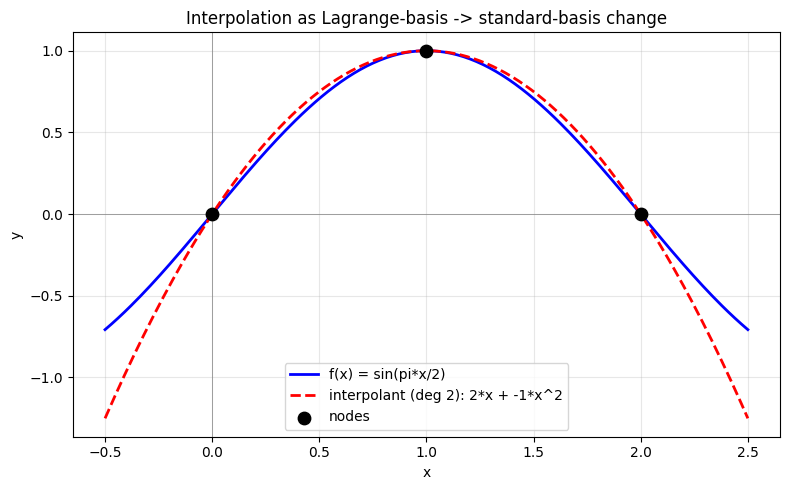

In [14]:
# Plot the interpolant alongside f
xs = np.linspace(-0.5, 2.5, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, np.sin(np.pi * xs / 2), 'b-', lw=2, label='f(x) = sin(pi*x/2)')
ax.plot(xs, [poly_eval(p_coeffs, x) for x in xs], 'r--', lw=2,
        label=f'interpolant (deg 2): {poly_str(p_coeffs)}')
ax.scatter(nodes, y_vals, color='k', zorder=5, s=80, label='nodes')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Interpolation as Lagrange-basis -> standard-basis change')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Bonus — composition of `D` and `I` is matrix multiplication

The composition formula `[T ∘ S]_{𝓓 ← 𝓑} = [T]_{𝓓 ← 𝓒} [S]_{𝓒 ← 𝓑}` (§6.8.4) means: composing two linear maps is just multiplying their matrices. Quick numerical check using our derivative and integration matrices.

In [15]:
# D and I3 are both 4x4 (acting on P_3 in standard basis).
# Theory says D @ I3 = identity on the part below x^3 (since truncation kills x^4).
print('D @ I3 (expected: identity on indices 0, 1, 2; zero on index 3):')
print(D @ I3)
print()
print('I3 @ D (expected: identity on indices 1, 2, 3; zero on index 0):')
print(I3 @ D)
print()
print('Both match the calculus identity F.T.O.C. — at the matrix level.')

D @ I3 (expected: identity on indices 0, 1, 2; zero on index 3):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]]

I3 @ D (expected: identity on indices 1, 2, 3; zero on index 0):
[[0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Both match the calculus identity F.T.O.C. — at the matrix level.


## Recap

We've now built the Ch 6 machinery in code:

- `Pₙ ≅ ℝⁿ⁺¹` via coefficient vectors.
- Linear maps between abstract spaces become **matrices** once we pick bases.
- The derivative is a 4×4 matrix on `P₃`; antidifferentiation is its (one-sided) inverse.
- Lagrange interpolation reduces to multiplying values by a single matrix `S`.
- Similarity `B = P A P⁻¹` is exactly the change-of-basis formula for linear operators.

In Chapter 7 we'll add **inner products** — the extra structure that gives us length, angle, and orthogonal projection. The Ch 1–5 machine still works; we just gain new tools.